# Temperature Scenario


In [1]:
# if running on google colab, uncomment the next line and execute this cell to install the dependencies and prevent "ModuleNotFoundError" in later cells:
# !pip install pvdeg

In [2]:
import pvdeg
import os

In [3]:
# This information helps with debugging and getting support :)
import sys
import platform

print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("pvdeg version ", pvdeg.__version__)

Working on a  Windows 11
Python version  3.13.13 | packaged by conda-forge | (main, Apr  8 2026, 01:56:49) [MSC v.1944 64 bit (AMD64)]
pvdeg version  0.7.2.dev86+gbddb1bdbc.d20260519


# Adding Modules and Pipeline Jobs (Run Functions on Scenario Object)

Material: `OX003` corresponds to a set of EVA material parameters from the default file `O2Permeation.json` in the `pvdeg/data` directory. Look in these files to see available options.

In [ ]:
scene_temp = pvdeg.Scenario(
    name="temperature and degradation",
    api_key="DEMO_KEY",
    email="user@mail.com",
)

scene_temp.addLocation(
    lat_long=(25.783388, -80.189029),
)

# this module will be overwritten because another with the same name is added afterwards
scene_temp.addModule(module_name="sapm_1", temperature_model="sapm")

scene_temp.addModule(
    module_name="sapm_1",
    racking="open_rack_glass_polymer",
    materials="OX003",
    temperature_model="sapm",
    irradiance_kwarg={"azimuth": 120, "tilt": 30},
    model_kwarg={"irrad_ref": 1100},
)

scene_temp.addModule(
    module_name="pvsyst_1",
    racking="freestanding",
    materials="OX003",
    temperature_model="pvsyst",
    irradiance_kwarg={"azimuth": 180, "tilt": 0},
    model_kwarg={"module_efficiency": 0.15},
)
scene_temp.addModule(
    module_name="sapm_2",
    racking="open_rack_glass_polymer",
    materials="OX003",
    temperature_model="sapm",
    irradiance_kwarg={"azimuth": 120, "tilt": 30},
    model_kwarg={"irrad_ref": 1000},
)
scene_temp.addModule(
    module_name="sapm_3",
    racking="open_rack_glass_polymer",
    materials="OX003",
    temperature_model="sapm",
    irradiance_kwarg={"azimuth": 180, "tilt": 0},
    model_kwarg={"irrad_ref": 1000},
)

scene_temp.addModule(
    module_name="pvsyst_2",
    racking="freestanding",
    materials="OX003",
    temperature_model="pvsyst",
    irradiance_kwarg={"azimuth": 180, "tilt": 0},
    model_kwarg={"module_efficiency": 0.2},
)

scene_temp.addJob(
    func=(pvdeg.temperature.temperature, {"cell_or_mod": "cell"}),
)

scene_temp.addJob(
    func=(pvdeg.degradation.vantHoff_deg, {"I_chamber": 1000, "temp_chamber": 25}),
)

scene_temp.addJob(
    func=(pvdeg.degradation.vantHoff_deg, {"I_chamber": 1000, "temp_chamber": 30}),
)

scene_temp.addJob(
    func=pvdeg.degradation.IwaVantHoff,
)


 Column "relative_humidity" not found in DataFrame. Calculating...


C:\Users\rdaxini\Documents\GitHub\PVDegradationTools_NREL\pvdeg\scenario.py:367: UserWarning: WARNING - Module already found by name "sapm_1"
  warnings.warn(f'WARNING - Module already found by name "{module_name}"')
C:\Users\rdaxini\Documents\GitHub\PVDegradationTools_NREL\pvdeg\scenario.py:368: UserWarning: Module will be replaced with new instance.
  warnings.warn("Module will be replaced with new instance.")


# Run and View Scenario Results

In [5]:
scene_temp.run()

scene_temp

,0
2019-01-01 00:30:00-05:00,24.100000
2019-01-01 01:30:00-05:00,24.100000
2019-01-01 02:30:00-05:00,24.000000
2019-01-01 03:30:00-05:00,24.000000
2019-01-01 04:30:00-05:00,24.000000
2019-01-01 05:30:00-05:00,23.900000
2019-01-01 06:30:00-05:00,24.000000
2019-01-01 07:30:00-05:00,25.680763
2019-01-01 08:30:00-05:00,29.424296
2019-01-01 09:30:00-05:00,35.939976


In [6]:
scene_temp.dump()

# Plotting and Extracting Results
These methods are independent of one another (i.e. you do not need to extract before plotting but both are shown below.)

In [7]:
import datetime

t0 = datetime.datetime(1970, 1, 1, 0, 0)
tf = datetime.datetime(1970, 1, 1, 23, 59)

# scene_temp.results is keyed by module_name, whose values are dicts keyed by
# job_id. Grab the first job_id from any module to use as the ('function', ...)
# target for extract/plot.
first_module_results = next(iter(scene_temp.results.values()))
first_job_id = next(iter(first_module_results.keys()))

temp_df = scene_temp.extract(
    ("function", first_job_id), tmy=True, start_time=t0, end_time=tf
)
display(temp_df)

,sapm_1,pvsyst_1,sapm_2,sapm_3,pvsyst_2
1970-01-01 00:30:00-05:00,24.100000,24.100000,24.100000,24.100000,24.100000
1970-01-01 01:30:00-05:00,24.100000,24.100000,24.100000,24.100000,24.100000
1970-01-01 02:30:00-05:00,24.000000,24.000000,24.000000,24.000000,24.000000
1970-01-01 03:30:00-05:00,24.000000,24.000000,24.000000,24.000000,24.000000
1970-01-01 04:30:00-05:00,24.000000,24.000000,24.000000,24.000000,24.000000
1970-01-01 05:30:00-05:00,23.900000,23.900000,23.900000,23.900000,23.900000
1970-01-01 06:30:00-05:00,24.000000,24.000000,24.000000,24.000000,24.000000
1970-01-01 07:30:00-05:00,27.565173,25.680763,27.609768,25.351273,25.611306
1970-01-01 08:30:00-05:00,30.664107,29.424296,30.749572,28.055360,29.169925
1970-01-01 09:30:00-05:00,37.165736,35.939976,37.348417,32.527241,35.319977


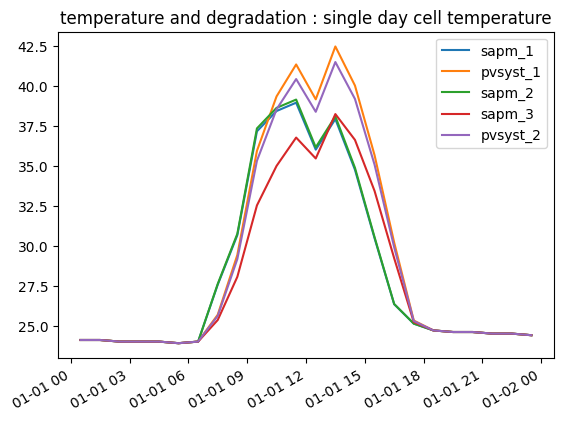

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'temperature and degradation : single day cell temperature'}>)

In [8]:
scene_temp.plot(
    ("function", first_job_id),
    tmy=True,
    start_time=t0,
    end_time=tf,
    title="single day cell temperature",
)

# Create a Copy of a Scenario

In [9]:

# the scenario fixture ships inside the pvdeg package, so this resolves from a pip
# install as well as a repo clone
new_path = pvdeg.DATA_DIR / "temperature_and_degradation.json"

copy = pvdeg.scenario.Scenario.load_json(
    file_path=str(new_path),
    email="user@mail.com",
    api_key="DEMO_KEY",
)

copy

credentials not in json file using arguments



 Column "relative_humidity" not found in DataFrame. Calculating...


,Year,Month,Day,Hour,Minute,temp_air,dew_point,dhi,dni,ghi,albedo,pressure,wind_direction,wind_speed,relative_humidity
0,2019,1,1,0,30,24.1,21.8,0.0,0.0,0.0,0.08,1019.0,128.0,3.6,87.000575
1,2019,1,1,1,30,24.1,21.7,0.0,0.0,0.0,0.08,1019.0,126.0,3.5,86.470668
2,2019,1,1,2,30,24.0,21.5,0.0,0.0,0.0,0.08,1019.0,124.0,3.4,85.933794
3,2019,1,1,3,30,24.0,21.1,0.0,0.0,0.0,0.08,1019.0,122.0,3.4,83.852221
4,2019,1,1,4,30,24.0,20.9,0.0,0.0,0.0,0.08,1019.0,121.0,3.5,82.828112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2024,12,31,19,30,24.4,21.7,0.0,0.0,0.0,0.08,1020.0,128.0,4.3,84.92921
8756,2024,12,31,20,30,24.3,21.8,0.0,0.0,0.0,0.08,1020.0,128.0,4.2,85.963157
8757,2024,12,31,21,30,24.2,21.8,0.0,0.0,0.0,0.08,1020.0,128.0,4.0,86.480116
8758,2024,12,31,22,30,24.2,21.9,0.0,0.0,0.0,0.08,1019.0,128.0,3.9,87.00968
